# Uber Urban Mobility & Demand Intelligence
### NYC High-Volume For-Hire Vehicle (FHVHV) — January 2026

**Portfolio Data Analytics Project**

This project analyzes more than **20 million NYC FHVHV trip records** to understand demand patterns, trip performance, geographic mobility, service behavior, and trip economics.

### Business objectives
- Identify when ride demand is strongest.
- Compare peak and non-peak operating performance.
- Understand geographic demand and movement patterns.
- Examine fare and driver-pay behavior.
- Segment trips by distance and duration.
- Use descriptive statistics and correlation to support EDA findings.
- Produce decision-ready insights for a later Power BI dashboard.

### Technical approach
Because the source Parquet file is several GB, the workflow uses **PyArrow row groups and memory-safe aggregation** instead of loading the complete dataset into Pandas at once.

> **Scope note:** SQL is intentionally excluded from this project and will be demonstrated in a separate portfolio project.

## 1. Environment & Data Setup

In [1]:
import os
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RAW_PATH = Path("fhvhv_tripdata_2026-01.parquet")
CLEAN_PATH = Path("Uber_cleaned.parquet")
ZONE_PATH = Path("taxi_zone_lookup.csv")

### Source-file structure

The raw trip file is too large to load safely into memory on a typical laptop.  
The first step is therefore to inspect Parquet metadata and a single row group.

In [2]:
raw_pf = pq.ParquetFile(RAW_PATH)

print(f"Raw rows: {raw_pf.metadata.num_rows:,}")
print(f"Columns: {raw_pf.metadata.num_columns}")
print(f"Row groups: {raw_pf.num_row_groups}")

sample = raw_pf.read_row_group(0).to_pandas()
print(f"First row-group shape: {sample.shape}")
print(
    f"First row-group memory: "
    f"{sample.memory_usage(deep=True).sum() / 1024**2:,.1f} MB"
)

Raw rows: 20,940,373
Columns: 25
Row groups: 20
First row-group shape: (1048576, 25)
First row-group memory: 534.0 MB


## 2. Data Quality Assessment

The initial quality review focused on issues that could invalidate operational or economic analysis:

- negative base passenger fares,
- impossible timestamp sequences,
- non-positive actual trip duration,
- zero-distance trips,
- zero recorded trip time.

Zero-distance and zero-time records are **flagged rather than globally deleted** because their relevance depends on the metric being analyzed.

In [3]:
def scan_quality(parquet_file):
    totals = {
        "rows": 0,
        "negative_fare": 0,
        "zero_miles": 0,
        "zero_trip_time": 0,
        "invalid_timestamp_sequence": 0,
        "nonpositive_actual_duration": 0,
    }

    cols = [
        "request_datetime", "on_scene_datetime",
        "pickup_datetime", "dropoff_datetime",
        "trip_miles", "trip_time", "base_passenger_fare"
    ]

    for i in range(parquet_file.num_row_groups):
        chunk = parquet_file.read_row_group(i, columns=cols).to_pandas()

        actual_seconds = (
            chunk["dropoff_datetime"] - chunk["pickup_datetime"]
        ).dt.total_seconds()

        timestamp_invalid = (
            (chunk["on_scene_datetime"] < chunk["request_datetime"]) |
            (chunk["pickup_datetime"] < chunk["on_scene_datetime"]) |
            (chunk["dropoff_datetime"] < chunk["pickup_datetime"])
        )

        totals["rows"] += len(chunk)
        totals["negative_fare"] += (chunk["base_passenger_fare"] < 0).sum()
        totals["zero_miles"] += (chunk["trip_miles"] == 0).sum()
        totals["zero_trip_time"] += (chunk["trip_time"] == 0).sum()
        totals["invalid_timestamp_sequence"] += timestamp_invalid.sum()
        totals["nonpositive_actual_duration"] += (actual_seconds <= 0).sum()

        del chunk
        gc.collect()

    return pd.Series(totals, name="count")

quality_summary = scan_quality(raw_pf)
quality_summary

rows                           20940373
negative_fare                     29965
zero_miles                         2782
zero_trip_time                      737
invalid_timestamp_sequence       357308
nonpositive_actual_duration           1
Name: count, dtype: int64

### Cleaning decision

Records are removed when they contain:
1. negative base passenger fare,
2. an invalid timestamp sequence, or
3. non-positive actual trip duration.

Zero mileage and zero recorded trip time are retained so they can be filtered only when a specific metric requires positive values.

## 3. Memory-Safe Cleaning Pipeline

In [4]:
def clean_chunk(chunk):
    chunk = chunk.copy()

    actual_seconds = (
        chunk["dropoff_datetime"] - chunk["pickup_datetime"]
    ).dt.total_seconds()

    timestamp_valid = (
        (chunk["request_datetime"] <= chunk["on_scene_datetime"]) &
        (chunk["on_scene_datetime"] <= chunk["pickup_datetime"]) &
        (chunk["pickup_datetime"] <= chunk["dropoff_datetime"])
    )

    clean_mask = (
        (chunk["base_passenger_fare"] >= 0) &
        timestamp_valid &
        (actual_seconds > 0)
    )

    cleaned = chunk.loc[clean_mask].copy()
    cleaned["actual_duration_seconds"] = actual_seconds.loc[clean_mask]

    return cleaned

In [5]:
# Build the cleaned checkpoint only when it does not already exist.
# This keeps downstream analysis fast and reproducible.

if not CLEAN_PATH.exists():
    writer = None

    for i in range(raw_pf.num_row_groups):
        chunk = raw_pf.read_row_group(i).to_pandas()
        cleaned = clean_chunk(chunk)

        table = pa.Table.from_pandas(cleaned, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(CLEAN_PATH, table.schema)

        writer.write_table(table)

        print(
            f"Row group {i + 1:02d}/{raw_pf.num_row_groups}: "
            f"{len(chunk):,} -> {len(cleaned):,}"
        )

        del chunk, cleaned, table
        gc.collect()

    writer.close()

### Cleaned checkpoint validation

In [6]:
parquet_file = pq.ParquetFile(CLEAN_PATH)

print(f"Cleaned rows: {parquet_file.metadata.num_rows:,}")
print(f"Columns: {parquet_file.metadata.num_columns}")
print(f"Row groups: {parquet_file.num_row_groups}")

Cleaned rows: 20,553,794
Columns: 26
Row groups: 20


**Final cleaned baseline:** **20,553,794 trips**.

All remaining analysis uses this cleaned checkpoint. Metric-specific filters are applied when positive distance, positive trip time, or non-negative driver pay are required.

## 4. Temporal Demand Analysis

### 4.1 Demand by hour of day

In [7]:
hourly_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["request_datetime"]
    ).to_pandas()

    chunk["request_hour"] = chunk["request_datetime"].dt.hour

    hourly_parts.append(
        chunk.groupby("request_hour").size().reset_index(name="trips")
    )

hourly_demand = (
    pd.concat(hourly_parts, ignore_index=True)
    .groupby("request_hour", as_index=False)["trips"]
    .sum()
)

assert hourly_demand["trips"].sum() == parquet_file.metadata.num_rows
hourly_demand.sort_values("trips", ascending=False).head()

,request_hour,trips
18,18,1255173
19,19,1220380
17,17,1212862
20,20,1134086
16,16,1095847


**Finding:** demand peaks in the late afternoon/evening, with **18:00** the busiest hour at roughly **1.26 million trips**. The strongest demand window is concentrated around **16:00–20:00**.

### 4.2 Demand by day of week

In [8]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

daily_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["request_datetime"]
    ).to_pandas()

    chunk["day_name"] = chunk["request_datetime"].dt.day_name()

    daily_parts.append(
        chunk.groupby("day_name").size().reset_index(name="trips")
    )

daily_demand = (
    pd.concat(daily_parts, ignore_index=True)
    .groupby("day_name", as_index=False)["trips"]
    .sum()
)

daily_demand["day_name"] = pd.Categorical(
    daily_demand["day_name"], categories=day_order, ordered=True
)
daily_demand = daily_demand.sort_values("day_name")
daily_demand

,day_name,trips
1,Monday,2154655
5,Tuesday,2481188
6,Wednesday,2550387
4,Thursday,3442752
0,Friday,3693173
2,Saturday,4001878
3,Sunday,2229761


**Finding:** Saturday records the highest total demand, followed by Friday. Demand patterns are not explained by a simple weekday/weekend split; **Friday and Saturday evenings** form the most concentrated high-demand periods.

### 4.3 Day × hour demand

In [9]:
day_hour_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["request_datetime"]
    ).to_pandas()

    chunk["day_name"] = chunk["request_datetime"].dt.day_name()
    chunk["request_hour"] = chunk["request_datetime"].dt.hour

    day_hour_parts.append(
        chunk.groupby(["day_name", "request_hour"])
        .size()
        .reset_index(name="trips")
    )

day_hour_demand = (
    pd.concat(day_hour_parts, ignore_index=True)
    .groupby(["day_name", "request_hour"], as_index=False)["trips"]
    .sum()
)

day_hour_demand.sort_values("trips", ascending=False).head(10)

,day_name,request_hour,trips
67,Saturday,19,254890
66,Saturday,18,249195
19,Friday,19,237726
18,Friday,18,235844
68,Saturday,20,234486
70,Saturday,22,233381
65,Saturday,17,232173
69,Saturday,21,220906
71,Saturday,23,220068
17,Friday,17,218186


**Finding:** the strongest recurring demand combinations occur on **Friday and Saturday evenings**. Saturday 19:00 is the single busiest day-hour combination.

## 5. Trip Performance & Economics

### 5.1 Overall trip performance

In [10]:
trip_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["trip_miles", "trip_time"]
    ).to_pandas()

    valid = chunk[
        (chunk["trip_miles"] > 0) &
        (chunk["trip_time"] > 0)
    ]

    trip_parts.append({
        "trips": len(valid),
        "miles": valid["trip_miles"].sum(),
        "seconds": valid["trip_time"].sum()
    })

trip_summary = pd.DataFrame(trip_parts).sum()

overall_performance = pd.Series({
    "valid_trips": trip_summary["trips"],
    "avg_distance_miles": trip_summary["miles"] / trip_summary["trips"],
    "avg_duration_minutes": (
        trip_summary["seconds"] / trip_summary["trips"] / 60
    ),
    "aggregate_speed_mph": (
        trip_summary["miles"] /
        (trip_summary["seconds"] / 3600)
    )
})

overall_performance

valid_trips            20,551,246.0000
avg_distance_miles              4.5435
avg_duration_minutes           18.5390
aggregate_speed_mph            14.7048
dtype: float64

**Finding:** valid trips average about **4.54 miles**, **18.54 minutes**, and **14.70 mph aggregate speed**.

### 5.2 Peak vs non-peak mobility

In [11]:
peak_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=["request_datetime", "trip_miles", "trip_time"]
    ).to_pandas()

    chunk["period"] = np.where(
        chunk["request_datetime"].dt.hour.between(16, 20),
        "Peak",
        "Non-Peak"
    )

    valid = chunk[
        (chunk["trip_miles"] > 0) &
        (chunk["trip_time"] > 0)
    ]

    temp = (
        valid.groupby("period")
        .agg(
            trips=("trip_miles", "size"),
            miles=("trip_miles", "sum"),
            seconds=("trip_time", "sum")
        )
        .reset_index()
    )

    peak_parts.append(temp)

peak_performance = (
    pd.concat(peak_parts, ignore_index=True)
    .groupby("period", as_index=False)
    .agg(
        trips=("trips", "sum"),
        miles=("miles", "sum"),
        seconds=("seconds", "sum")
    )
)

peak_performance["avg_distance"] = (
    peak_performance["miles"] / peak_performance["trips"]
)
peak_performance["avg_duration_min"] = (
    peak_performance["seconds"] / peak_performance["trips"] / 60
)
peak_performance["aggregate_speed_mph"] = (
    peak_performance["miles"] /
    (peak_performance["seconds"] / 3600)
)

peak_performance

,period,trips,miles,seconds,avg_distance,avg_duration_min,aggregate_speed_mph
0,Non-Peak,14633399,"68,324,420.0900",16099991643,4.6691,18.3370,15.2775
1,Peak,5917847,"25,050,669.9130",6759982135,4.2331,19.0384,13.3406


**Finding:** compared with non-peak trips, peak-period trips are roughly **9% shorter**, take about **4% longer**, and have approximately **13% lower aggregate speed**. This is an association with the peak window, not proof of causation.

### 5.3 Peak vs non-peak economics

In [12]:
econ_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "request_datetime", "trip_miles",
            "base_passenger_fare", "driver_pay", "tips"
        ]
    ).to_pandas()

    chunk["period"] = np.where(
        chunk["request_datetime"].dt.hour.between(16, 20),
        "Peak",
        "Non-Peak"
    )

    valid = chunk[chunk["trip_miles"] > 0]

    temp = (
        valid.groupby("period")
        .agg(
            trips=("trip_miles", "size"),
            total_miles=("trip_miles", "sum"),
            total_fare=("base_passenger_fare", "sum"),
            total_driver_pay=("driver_pay", "sum"),
            total_tips=("tips", "sum")
        )
        .reset_index()
    )

    econ_parts.append(temp)

peak_economics = (
    pd.concat(econ_parts, ignore_index=True)
    .groupby("period", as_index=False)
    .sum(numeric_only=True)
)

peak_economics["avg_fare"] = (
    peak_economics["total_fare"] / peak_economics["trips"]
)
peak_economics["avg_driver_pay"] = (
    peak_economics["total_driver_pay"] / peak_economics["trips"]
)
peak_economics["avg_tip"] = (
    peak_economics["total_tips"] / peak_economics["trips"]
)
peak_economics["fare_per_mile"] = (
    peak_economics["total_fare"] / peak_economics["total_miles"]
)
peak_economics["driver_pay_per_mile"] = (
    peak_economics["total_driver_pay"] / peak_economics["total_miles"]
)

peak_economics

,period,trips,total_miles,total_fare,total_driver_pay,total_tips,avg_fare,avg_driver_pay,avg_tip,fare_per_mile,driver_pay_per_mile
0,Non-Peak,14633399,"68,324,420.0900","371,546,647.9300","286,732,911.0100","16,336,232.3400",25.3903,19.5944,1.1164,5.4380,4.1966
1,Peak,5917847,"25,050,669.9130","147,629,785.8500","114,395,812.6700","6,839,622.5000",24.9465,19.3306,1.1558,5.8932,4.5666


**Finding:** peak trips have slightly lower average fare and driver pay per trip, but higher fare and driver-pay density per mile. These measures describe recorded trip economics; they do not measure driver profitability.

### 5.4 Driver pay per passenger trip-hour

In [13]:
hourly_pay_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=["request_datetime", "trip_time", "driver_pay"]
    ).to_pandas()

    valid = chunk[
        (chunk["trip_time"] > 0) &
        (chunk["driver_pay"] >= 0)
    ].copy()

    valid["request_hour"] = valid["request_datetime"].dt.hour

    temp = (
        valid.groupby("request_hour")
        .agg(
            trips=("driver_pay", "size"),
            total_driver_pay=("driver_pay", "sum"),
            total_seconds=("trip_time", "sum")
        )
        .reset_index()
    )

    hourly_pay_parts.append(temp)

hourly_driver_summary = (
    pd.concat(hourly_pay_parts, ignore_index=True)
    .groupby("request_hour", as_index=False)
    .agg(
        trips=("trips", "sum"),
        total_driver_pay=("total_driver_pay", "sum"),
        total_seconds=("total_seconds", "sum")
    )
)

hourly_driver_summary["driver_pay_per_trip_hour"] = (
    hourly_driver_summary["total_driver_pay"] /
    (hourly_driver_summary["total_seconds"] / 3600)
)

hourly_driver_summary

,request_hour,trips,total_driver_pay,total_seconds,driver_pay_per_trip_hour
0,0,705620,"13,310,255.9000",707323344,67.7440
1,1,500903,"9,714,325.3200",490340788,71.3210
2,2,373708,"7,355,673.9200",365509757,72.4479
3,3,306982,"5,972,267.9600",306207472,70.2144
4,4,295145,"5,933,222.3900",298089096,71.6551
5,5,365692,"7,666,139.9800",390539913,70.6665
6,6,582568,"12,360,607.9100",650295138,68.4277
7,7,883051,"18,202,811.3200",997844107,65.6717
8,8,1032912,"20,226,346.5200",1144188061,63.6389
9,9,945513,"17,593,521.6700",1028128942,61.6038


**Finding:** the highest demand hours and the highest passenger-trip-time pay hours do not perfectly overlap. **20:00–22:00** provides a useful balance of strong demand and above-median trip-time pay.

> `driver_pay_per_trip_hour` is **not actual online hourly earnings** because idle time, waiting, deadheading, fuel, and other costs are excluded.

## 6. Geographic & Mobility Analysis

In [14]:
taxi_zone_lookup = pd.read_csv(ZONE_PATH)
taxi_zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### 6.1 Pickup and drop-off hotspots

In [15]:
pickup_parts = []
dropoff_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["PULocationID", "DOLocationID"]
    ).to_pandas()

    pickup_parts.append(
        chunk.groupby("PULocationID").size().reset_index(name="trips")
    )
    dropoff_parts.append(
        chunk.groupby("DOLocationID").size().reset_index(name="trips")
    )

pickup_demand = (
    pd.concat(pickup_parts, ignore_index=True)
    .groupby("PULocationID", as_index=False)["trips"]
    .sum()
)

dropoff_demand = (
    pd.concat(dropoff_parts, ignore_index=True)
    .groupby("DOLocationID", as_index=False)["trips"]
    .sum()
)

pickup_named = pickup_demand.merge(
    taxi_zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

dropoff_named = dropoff_demand.merge(
    taxi_zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

pickup_named.sort_values("trips", ascending=False).head(10)

,PULocationID,trips,LocationID,Borough,Zone
135,138,358356,138,Queens,LaGuardia Airport
129,132,326009,132,Queens,JFK Airport
60,61,272504,61,Brooklyn,Crown Heights North
36,37,242981,37,Brooklyn,Bushwick South
75,76,242092,76,Brooklyn,East New York
78,79,239466,79,Manhattan,East Village
227,230,222731,230,Manhattan,Times Sq/Theatre District
158,161,222179,161,Manhattan,Midtown Center
252,255,210897,255,Brooklyn,Williamsburg (North Side)
178,181,210851,181,Brooklyn,Park Slope


**Finding:** **LaGuardia Airport and JFK Airport** are the two largest individual pickup zones, but together they represent only about **3.33% of all cleaned trips**. Demand is therefore geographically distributed rather than airport-dominated.

### 6.2 Origin–destination movement

In [16]:
route_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["PULocationID", "DOLocationID"]
    ).to_pandas()

    route_parts.append(
        chunk.groupby(["PULocationID", "DOLocationID"])
        .size()
        .reset_index(name="trips")
    )

routes_base = (
    pd.concat(route_parts, ignore_index=True)
    .groupby(["PULocationID", "DOLocationID"], as_index=False)["trips"]
    .sum()
)

pickup_lookup = taxi_zone_lookup[
    ["LocationID", "Borough", "Zone"]
].rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough",
    "Zone": "pickup_zone"
})

dropoff_lookup = taxi_zone_lookup[
    ["LocationID", "Borough", "Zone"]
].rename(columns={
    "LocationID": "DOLocationID",
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone"
})

routes_named = (
    routes_base
    .merge(
        pickup_lookup,
        on="PULocationID",
        how="left",
        validate="many_to_one"
    )
    .merge(
        dropoff_lookup,
        on="DOLocationID",
        how="left",
        validate="many_to_one"
    )
)

routes_named.sort_values("trips", ascending=False).head(15)

,PULocationID,DOLocationID,trips,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone
16560,76,76,82964,Brooklyn,East New York,Brooklyn,East New York
28553,132,265,61607,Queens,JFK Airport,NaN,Outside of NYC
5130,26,26,57061,Brooklyn,Borough Park,Brooklyn,Borough Park
7968,39,39,50106,Brooklyn,Canarsie,Brooklyn,Canarsie
30008,138,265,43123,Queens,LaGuardia Airport,NaN,Outside of NYC
2259,14,14,40235,Brooklyn,Bay Ridge,Brooklyn,Bay Ridge
12881,61,61,37482,Brooklyn,Crown Heights North,Brooklyn,Crown Heights North
21141,95,95,34881,Queens,Forest Hills,Queens,Forest Hills
822,7,7,34560,Queens,Astoria,Queens,Astoria
27676,129,129,34405,Queens,Jackson Heights,Queens,Jackson Heights


In [17]:
routes_base["zone_movement"] = np.where(
    routes_base["PULocationID"] == routes_base["DOLocationID"],
    "Same Zone",
    "Different Zone"
)

zone_movement = (
    routes_base.groupby("zone_movement", as_index=False)["trips"]
    .sum()
)

zone_movement["percentage"] = (
    zone_movement["trips"] / zone_movement["trips"].sum() * 100
)

routes_named["borough_movement"] = np.select(
    [
        routes_named["dropoff_zone"].eq("Outside of NYC"),
        routes_named["pickup_borough"].eq(routes_named["dropoff_borough"])
    ],
    [
        "Outside NYC",
        "Within Borough"
    ],
    default="Cross Borough"
)

borough_movement = (
    routes_named.groupby("borough_movement", as_index=False)["trips"]
    .sum()
)

borough_movement["percentage"] = (
    borough_movement["trips"] /
    borough_movement["trips"].sum() * 100
)

display(zone_movement)
display(borough_movement)

,zone_movement,trips,percentage
0,Different Zone,18706682,91.0133
1,Same Zone,1847112,8.9867


,borough_movement,trips,percentage
0,Cross Borough,4623223,22.4933
1,Outside NYC,819240,3.9858
2,Within Borough,15111331,73.5209


**Finding:** approximately **91%** of trips cross a taxi-zone boundary, yet about **73.5%** remain within the same borough. This indicates movement that is highly dispersed across neighborhoods while still being predominantly local at the broader borough level. Crossing a zone boundary should not be interpreted as a long-distance trip.

### 6.3 Borough pickup and drop-off flows

In [18]:
borough_pickup = (
    pickup_named.groupby("Borough", dropna=False, as_index=False)["trips"]
    .sum()
    .rename(columns={"trips": "pickups"})
)

borough_dropoff = (
    dropoff_named.groupby("Borough", dropna=False, as_index=False)["trips"]
    .sum()
    .rename(columns={"trips": "dropoffs"})
)

borough_flow = borough_pickup.merge(
    borough_dropoff, on="Borough", how="outer"
)

borough_flow["net_flow"] = (
    borough_flow["dropoffs"] - borough_flow["pickups"]
)

borough_flow.sort_values("pickups", ascending=False)

,Borough,pickups,dropoffs,net_flow
3,Manhattan,"7,152,427.0000",6584106,"-568,321.0000"
1,Brooklyn,"5,814,405.0000",5807829,"-6,576.0000"
4,Queens,"4,513,490.0000",4308968,"-204,522.0000"
0,Bronx,"2,743,399.0000",2604138,"-139,261.0000"
5,Staten Island,"329,075.0000",320500,"-8,575.0000"
7,NaN,997.0000,819240,"818,243.0000"
2,EWR,1.0000,108669,"108,668.0000"
6,Unknown,NaN,344,NaN


**Finding:** Manhattan is the largest pickup market and records roughly **568K more pickups than drop-offs**, while Brooklyn is nearly balanced. This describes directional passenger flows; it does not directly measure driver repositioning.

### 6.4 Zone-level trip performance

In [19]:
zone_perf_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["PULocationID", "trip_miles", "trip_time"]
    ).to_pandas()

    valid = chunk[
        (chunk["trip_miles"] > 0) &
        (chunk["trip_time"] > 0)
    ]

    temp = (
        valid.groupby("PULocationID")
        .agg(
            trips=("trip_miles", "size"),
            total_miles=("trip_miles", "sum"),
            total_seconds=("trip_time", "sum")
        )
        .reset_index()
    )

    zone_perf_parts.append(temp)

zone_performance = (
    pd.concat(zone_perf_parts, ignore_index=True)
    .groupby("PULocationID", as_index=False)
    .agg(
        trips=("trips", "sum"),
        total_miles=("total_miles", "sum"),
        total_seconds=("total_seconds", "sum")
    )
)

zone_performance["avg_distance"] = (
    zone_performance["total_miles"] / zone_performance["trips"]
)
zone_performance["avg_duration_min"] = (
    zone_performance["total_seconds"] /
    zone_performance["trips"] / 60
)
zone_performance["aggregate_speed_mph"] = (
    zone_performance["total_miles"] /
    (zone_performance["total_seconds"] / 3600)
)

zone_performance = zone_performance.merge(
    taxi_zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

zone_performance.sort_values("trips", ascending=False).head(20)

,PULocationID,trips,total_miles,total_seconds,avg_distance,avg_duration_min,aggregate_speed_mph,LocationID,Borough,Zone
135,138,358352,"4,024,167.7970",685178780,11.2297,31.8671,21.1434,138,Queens,LaGuardia Airport
129,132,325958,"5,782,614.9320",834643886,17.7404,42.6765,24.9417,132,Queens,JFK Airport
60,61,272474,"919,028.2300",297524179,3.3729,18.1989,11.1201,61,Brooklyn,Crown Heights North
36,37,242945,"898,586.8270",275482767,3.6987,18.8988,11.7427,37,Brooklyn,Bushwick South
75,76,242059,"853,628.5760",233955353,3.5265,16.1087,13.1353,76,Brooklyn,East New York
78,79,239423,"967,991.0490",264666057,4.0430,18.4239,13.1667,79,Manhattan,East Village
227,230,222698,"1,296,627.4250",302626676,5.8224,22.6485,15.4245,230,Manhattan,Times Sq/Theatre District
158,161,222154,"1,126,279.3770",292361854,5.0698,21.9339,13.8685,161,Manhattan,Midtown Center
252,255,210863,"819,247.7520",238639800,3.8852,18.8622,12.3588,255,Brooklyn,Williamsburg (North Side)
178,181,210839,"823,162.0800",239398772,3.9042,18.9243,12.3784,181,Brooklyn,Park Slope


**Finding:** airport-origin trips have very different mobility profiles from major urban hotspots. JFK trips average about **17.74 miles / 42.68 minutes**, while LaGuardia averages about **11.23 miles / 31.87 minutes**.

### 6.5 Zone-level economics

In [20]:
zone_econ_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "PULocationID", "trip_miles", "trip_time",
            "base_passenger_fare", "driver_pay"
        ]
    ).to_pandas()

    valid = chunk[
        (chunk["trip_miles"] > 0) &
        (chunk["trip_time"] > 0) &
        (chunk["driver_pay"] >= 0)
    ]

    temp = (
        valid.groupby("PULocationID")
        .agg(
            trips=("trip_miles", "size"),
            miles=("trip_miles", "sum"),
            seconds=("trip_time", "sum"),
            fare=("base_passenger_fare", "sum"),
            driver_pay=("driver_pay", "sum")
        )
        .reset_index()
    )

    zone_econ_parts.append(temp)

zone_economics = (
    pd.concat(zone_econ_parts, ignore_index=True)
    .groupby("PULocationID", as_index=False)
    .sum(numeric_only=True)
)

zone_economics["avg_fare"] = (
    zone_economics["fare"] / zone_economics["trips"]
)
zone_economics["avg_driver_pay"] = (
    zone_economics["driver_pay"] / zone_economics["trips"]
)
zone_economics["fare_per_mile"] = (
    zone_economics["fare"] / zone_economics["miles"]
)
zone_economics["driver_pay_per_mile"] = (
    zone_economics["driver_pay"] / zone_economics["miles"]
)
zone_economics["driver_pay_per_trip_hour"] = (
    zone_economics["driver_pay"] /
    (zone_economics["seconds"] / 3600)
)

zone_economics = zone_economics.merge(
    taxi_zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

zone_economics.sort_values("trips", ascending=False).head(20)

,PULocationID,trips,miles,seconds,fare,driver_pay,avg_fare,avg_driver_pay,fare_per_mile,driver_pay_per_mile,driver_pay_per_trip_hour,LocationID,Borough,Zone
135,138,358352,"4,024,167.7970",685178780,"19,903,927.8700","14,293,249.5900",55.5430,39.8861,4.9461,3.5519,75.0982,138,Queens,LaGuardia Airport
129,132,325958,"5,782,614.9320",834643886,"24,777,446.1400","18,059,410.9300",76.0142,55.4041,4.2848,3.1231,77.8942,132,Queens,JFK Airport
60,61,272472,"919,016.1900",297518250,"5,570,245.2700","4,697,956.9100",20.4434,17.2420,6.0611,5.1119,56.8457,61,Brooklyn,Crown Heights North
36,37,242945,"898,586.8270",275482767,"5,298,061.2600","4,431,631.5600",21.8077,18.2413,5.8960,4.9318,57.9124,37,Brooklyn,Bushwick South
75,76,242058,"853,623.5160",233953228,"4,318,070.1900","3,759,395.0600",17.8390,15.5310,5.0585,4.4040,57.8484,76,Brooklyn,East New York
78,79,239423,"967,991.0490",264666057,"6,271,260.0900","4,586,891.1600",26.1932,19.1581,6.4786,4.7386,62.3911,79,Manhattan,East Village
227,230,222697,"1,296,617.3650",302624246,"9,117,467.1700","5,872,745.2900",40.9411,26.3710,7.0317,4.5293,69.8618,230,Manhattan,Times Sq/Theatre District
158,161,222154,"1,126,279.3770",292361854,"9,058,266.0000","5,654,510.8800",40.7747,25.4531,8.0426,5.0205,69.6269,161,Manhattan,Midtown Center
252,255,210863,"819,247.7520",238639800,"5,265,916.2300","4,000,068.5500",24.9732,18.9700,6.4277,4.8826,60.3430,255,Brooklyn,Williamsburg (North Side)
178,181,210838,"823,156.8500",239396739,"4,919,663.2900","3,888,820.9100",23.3339,18.4446,5.9766,4.7243,58.4793,181,Brooklyn,Park Slope


**Finding:** JFK and LaGuardia generate high fare and driver pay per trip, while several central Manhattan zones generate higher fare density per mile. JFK has the highest passenger-trip-time driver pay among the highest-volume zones.

## 7. Service & Trip Behavior

### 7.1 Service-flag prevalence

In [21]:
service_cols = [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

counts = {col: {"Y": 0, "N": 0} for col in service_cols}

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=service_cols
    ).to_pandas()

    for col in service_cols:
        vc = chunk[col].value_counts()
        counts[col]["Y"] += int(vc.get("Y", 0))
        counts[col]["N"] += int(vc.get("N", 0))

service_summary = pd.DataFrame(counts).T
service_summary["total"] = service_summary["Y"] + service_summary["N"]
service_summary["yes_rate_pct"] = (
    service_summary["Y"] / service_summary["total"] * 100
)

service_summary

,Y,N,total,yes_rate_pct
shared_request_flag,388092,20165702,20553794,1.8882
shared_match_flag,227658,20326136,20553794,1.1076
access_a_ride_flag,18516,20535278,20553794,0.0901
wav_request_flag,38223,20515571,20553794,0.1860
wav_match_flag,1873392,18680402,20553794,9.1146


**Finding:** explicit shared-ride requests represent only about **1.89%** of trips. Explicit WAV requests and Access-A-Ride flags are also rare. WAV request/match fields should not be interpreted as a simple fulfillment funnel because their recorded semantics differ.

### 7.2 Shared request → recorded match

In [22]:
shared_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=["shared_request_flag", "shared_match_flag"]
    ).to_pandas()

    shared_parts.append(
        chunk.groupby(
            ["shared_request_flag", "shared_match_flag"]
        ).size().reset_index(name="trips")
    )

shared_crosstab = (
    pd.concat(shared_parts, ignore_index=True)
    .groupby(
        ["shared_request_flag", "shared_match_flag"],
        as_index=False
    )["trips"]
    .sum()
)

shared_requested = shared_crosstab[
    shared_crosstab["shared_request_flag"] == "Y"
]

requested_total = shared_requested["trips"].sum()
requested_and_matched = shared_requested.loc[
    shared_requested["shared_match_flag"] == "Y", "trips"
].sum()

shared_match_rate = requested_and_matched / requested_total * 100

print(f"Shared requests: {requested_total:,}")
print(f"Requested and matched: {requested_and_matched:,}")
print(f"Recorded match rate among shared requests: {shared_match_rate:.2f}%")

Shared requests: 388,092
Requested and matched: 225,952
Recorded match rate among shared requests: 58.22%


**Finding:** about **58.22%** of explicit shared requests were recorded as matched. The remainder should not be labelled as platform failures because the dataset does not identify why a request was not matched.

### 7.3 Distance segmentation

In [23]:
distance_bins = [0, 1, 3, 7, 15, np.inf]
distance_labels = [
    "Very Short (0–1 mi)",
    "Short (1–3 mi)",
    "Medium (3–7 mi)",
    "Long (7–15 mi)",
    "Very Long (15+ mi)"
]

distance_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["trip_miles"]
    ).to_pandas()

    valid = chunk[chunk["trip_miles"] > 0].copy()

    valid["distance_segment"] = pd.cut(
        valid["trip_miles"],
        bins=distance_bins,
        labels=distance_labels,
        right=True,
        include_lowest=False
    )

    distance_parts.append(
        valid.groupby(
            "distance_segment",
            observed=True
        ).size().reset_index(name="trips")
    )

distance_summary = (
    pd.concat(distance_parts, ignore_index=True)
    .groupby(
        "distance_segment",
        observed=True,
        as_index=False
    )["trips"]
    .sum()
)

distance_summary["percentage"] = (
    distance_summary["trips"] /
    distance_summary["trips"].sum() * 100
)

distance_summary

,distance_segment,trips,percentage
0,Very Short (0–1 mi),2746495,13.3641
1,Short (1–3 mi),8455599,41.1440
2,Medium (3–7 mi),5423030,26.3878
3,Long (7–15 mi),2915055,14.1843
4,Very Long (15+ mi),1011067,4.9197


**Finding:** **54.51%** of valid trips are three miles or less and **80.90%** are seven miles or less. Only about **4.92%** exceed 15 miles. These are analyst-defined segments, not official Uber categories.

### 7.4 Distance segment economics

In [24]:
segment_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "trip_miles", "trip_time",
            "base_passenger_fare", "driver_pay"
        ]
    ).to_pandas()

    valid = chunk[
        (chunk["trip_miles"] > 0) &
        (chunk["trip_time"] > 0) &
        (chunk["driver_pay"] >= 0)
    ].copy()

    valid["distance_segment"] = pd.cut(
        valid["trip_miles"],
        bins=distance_bins,
        labels=distance_labels,
        right=True,
        include_lowest=False
    )

    temp = (
        valid.groupby("distance_segment", observed=True)
        .agg(
            trips=("trip_miles", "size"),
            total_miles=("trip_miles", "sum"),
            total_seconds=("trip_time", "sum"),
            total_fare=("base_passenger_fare", "sum"),
            total_driver_pay=("driver_pay", "sum")
        )
        .reset_index()
    )

    segment_parts.append(temp)

segment_economics = (
    pd.concat(segment_parts, ignore_index=True)
    .groupby(
        "distance_segment",
        observed=True,
        as_index=False
    )
    .sum(numeric_only=True)
)

segment_economics["avg_distance"] = (
    segment_economics["total_miles"] /
    segment_economics["trips"]
)
segment_economics["avg_duration_min"] = (
    segment_economics["total_seconds"] /
    segment_economics["trips"] / 60
)
segment_economics["avg_fare"] = (
    segment_economics["total_fare"] /
    segment_economics["trips"]
)
segment_economics["avg_driver_pay"] = (
    segment_economics["total_driver_pay"] /
    segment_economics["trips"]
)
segment_economics["fare_per_mile"] = (
    segment_economics["total_fare"] /
    segment_economics["total_miles"]
)
segment_economics["driver_pay_per_trip_hour"] = (
    segment_economics["total_driver_pay"] /
    (segment_economics["total_seconds"] / 3600)
)

segment_economics

,distance_segment,trips,total_miles,total_seconds,total_fare,total_driver_pay,avg_distance,avg_duration_min,avg_fare,avg_driver_pay,fare_per_mile,driver_pay_per_trip_hour
0,Very Short (0–1 mi),2746495,"2,023,508.7020",1038085650,"27,100,804.5100","18,052,194.0500",0.7368,6.2995,9.8674,6.5728,13.3930,62.6036
1,Short (1–3 mi),8455598,"15,517,550.5540",6317091695,"132,111,228.5600","98,786,421.9100",1.8352,12.4515,15.6241,11.6830,8.5137,56.2967
2,Medium (3–7 mi),5423012,"24,921,266.8370",7084417250,"142,248,402.0800","115,889,517.7600",4.5955,21.7727,26.2305,21.3700,5.7079,58.8901
3,Long (7–15 mi),2915037,"28,925,790.4310",5480859816,"126,584,811.4900","101,767,713.3400",9.9230,31.3367,43.4248,34.9113,4.3762,66.8442
4,Very Long (15+ mi),1011064,"21,986,639.9090",2939404817,"91,131,168.5000","66,633,268.5800",21.7460,48.4540,90.1339,65.9041,4.1448,81.6083


**Finding:** average fare rises strongly with distance, while fare per mile falls. Very-long trips are uncommon but have much higher fare and passenger-trip-time driver pay per trip.

### 7.5 Duration segmentation

In [25]:
duration_bins = [0, 300, 900, 1800, 3600, np.inf]
duration_labels = [
    "Very Short (0–5 min)",
    "Short (5–15 min)",
    "Medium (15–30 min)",
    "Long (30–60 min)",
    "Very Long (60+ min)"
]

duration_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=["trip_time"]
    ).to_pandas()

    valid = chunk[chunk["trip_time"] > 0].copy()

    valid["duration_segment"] = pd.cut(
        valid["trip_time"],
        bins=duration_bins,
        labels=duration_labels,
        right=True,
        include_lowest=False
    )

    duration_parts.append(
        valid.groupby(
            "duration_segment",
            observed=True
        ).size().reset_index(name="trips")
    )

duration_summary = (
    pd.concat(duration_parts, ignore_index=True)
    .groupby(
        "duration_segment",
        observed=True,
        as_index=False
    )["trips"]
    .sum()
)

duration_summary["percentage"] = (
    duration_summary["trips"] /
    duration_summary["trips"].sum() * 100
)

duration_summary

,duration_segment,trips,percentage
0,Very Short (0–5 min),1121109,5.4547
1,Short (5–15 min),9004770,43.8122
2,Medium (15–30 min),7317241,35.6017
3,Long (30–60 min),2829918,13.7688
4,Very Long (60+ min),280051,1.3626


**Finding:** approximately **79.41%** of positive-duration trips last between **5 and 30 minutes**, while only **1.36%** exceed one hour.

## 8. Statistical Analysis

The statistical section intentionally uses methods that are straightforward to explain in an interview:

- mean, median and quartiles,
- standard deviation,
- coefficient of variation,
- skewness and IQR,
- Pearson correlation,
- descriptive group comparison.

No hypothesis testing is used in this project.

### 8.1 Pearson correlation — exact memory-safe calculation

In [26]:
corr_cols = [
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "driver_pay"
]

n_total = 0
sum_x = np.zeros(len(corr_cols))
sum_xy = np.zeros((len(corr_cols), len(corr_cols)))

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=corr_cols
    ).to_pandas()

    arr = chunk[corr_cols].dropna().to_numpy(dtype="float64")

    n_total += len(arr)
    sum_x += arr.sum(axis=0)
    sum_xy += arr.T @ arr

means = sum_x / n_total

cov_matrix = (
    sum_xy - n_total * np.outer(means, means)
) / (n_total - 1)

std_devs = np.sqrt(np.diag(cov_matrix))

corr_matrix = (
    cov_matrix / np.outer(std_devs, std_devs)
)

correlation_df = pd.DataFrame(
    corr_matrix,
    index=["Distance", "Duration", "Fare", "Driver Pay"],
    columns=["Distance", "Duration", "Fare", "Driver Pay"]
)

correlation_df.round(3)

,Distance,Duration,Fare,Driver Pay
Distance,1.0000,0.7830,0.8400,0.9010
Duration,0.7830,1.0000,0.7950,0.9020
Fare,0.8400,0.7950,1.0000,0.9300
Driver Pay,0.9010,0.9020,0.9300,1.0000


**Finding:** all four core measures are strongly positively related. The strongest relationship is between **fare and driver pay (~0.93)**. Distance is also strongly associated with both fare and driver pay. Correlation does not establish causation.

### 8.2 Relative variability

In [27]:
stats_cols = [
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "driver_pay"
]

n_total = 0
sum_x = np.zeros(len(stats_cols))
sum_x2 = np.zeros(len(stats_cols))

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i, columns=stats_cols
    ).to_pandas()

    arr = chunk[stats_cols].dropna().to_numpy(dtype="float64")

    n_total += len(arr)
    sum_x += arr.sum(axis=0)
    sum_x2 += (arr ** 2).sum(axis=0)

means = sum_x / n_total
variances = (
    sum_x2 - n_total * means**2
) / (n_total - 1)
std_devs = np.sqrt(variances)
cv_pct = std_devs / means * 100

variability_summary = pd.DataFrame({
    "Metric": [
        "Trip Distance (miles)",
        "Trip Duration (seconds)",
        "Base Passenger Fare ($)",
        "Driver Pay ($)"
    ],
    "Mean": means,
    "Std Dev": std_devs,
    "CV (%)": cv_pct
})

variability_summary

,Metric,Mean,Std Dev,CV (%)
0,Trip Distance (miles),4.5430,5.4118,119.1255
1,Trip Duration (seconds),"1,112.2308",779.1409,70.0521
2,Base Passenger Fare ($),25.2612,23.4537,92.8447
3,Driver Pay ($),19.5173,16.5000,84.5400


**Finding:** trip distance has the greatest relative variability, while duration is the least variable of the four core metrics on a coefficient-of-variation basis.

### 8.3 Distribution shape from a balanced row-group sample

In [28]:
sample_parts = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "trip_miles",
            "trip_time",
            "base_passenger_fare",
            "driver_pay"
        ]
    ).to_pandas()

    n = min(10_000, len(chunk))
    sample_parts.append(
        chunk.sample(n=n, random_state=42)
    )

stats_sample = pd.concat(sample_parts, ignore_index=True)
stats_sample["trip_duration_min"] = stats_sample["trip_time"] / 60

distribution_summary = pd.DataFrame({
    "Metric": [
        "Trip Distance (miles)",
        "Trip Duration (minutes)",
        "Base Passenger Fare ($)",
        "Driver Pay ($)"
    ],
    "Mean": [
        stats_sample["trip_miles"].mean(),
        stats_sample["trip_duration_min"].mean(),
        stats_sample["base_passenger_fare"].mean(),
        stats_sample["driver_pay"].mean()
    ],
    "Median": [
        stats_sample["trip_miles"].median(),
        stats_sample["trip_duration_min"].median(),
        stats_sample["base_passenger_fare"].median(),
        stats_sample["driver_pay"].median()
    ],
    "Q1": [
        stats_sample["trip_miles"].quantile(.25),
        stats_sample["trip_duration_min"].quantile(.25),
        stats_sample["base_passenger_fare"].quantile(.25),
        stats_sample["driver_pay"].quantile(.25)
    ],
    "Q3": [
        stats_sample["trip_miles"].quantile(.75),
        stats_sample["trip_duration_min"].quantile(.75),
        stats_sample["base_passenger_fare"].quantile(.75),
        stats_sample["driver_pay"].quantile(.75)
    ],
    "Skewness": [
        stats_sample["trip_miles"].skew(),
        stats_sample["trip_duration_min"].skew(),
        stats_sample["base_passenger_fare"].skew(),
        stats_sample["driver_pay"].skew()
    ]
})

distribution_summary["IQR"] = (
    distribution_summary["Q3"] - distribution_summary["Q1"]
)

distribution_summary

,Metric,Mean,Median,Q1,Q3,Skewness,IQR
0,Trip Distance (miles),4.5233,2.6500,1.4000,5.5800,5.1360,4.1800
1,Trip Duration (minutes),18.5225,15.2000,9.4500,23.8667,2.0546,14.4167
2,Base Passenger Fare ($),25.2766,18.2400,11.6400,30.0900,4.9185,18.4500
3,Driver Pay ($),19.4901,14.8200,8.8600,24.6500,4.1658,15.7900


**Finding:** all four core measures are right-skewed. For trip distance, the median is substantially below the mean, showing how a smaller long-distance tail pulls the average upward. Statistical outliers are not automatically data errors—for example, legitimate airport trips can be long.

## 9. Curated Python Visualizations

The notebook intentionally uses a **small set of decision-relevant charts**. Power BI will later provide the interactive executive layer; Python visuals are used here to demonstrate EDA and analytical reasoning.

### 9.1 Hourly demand

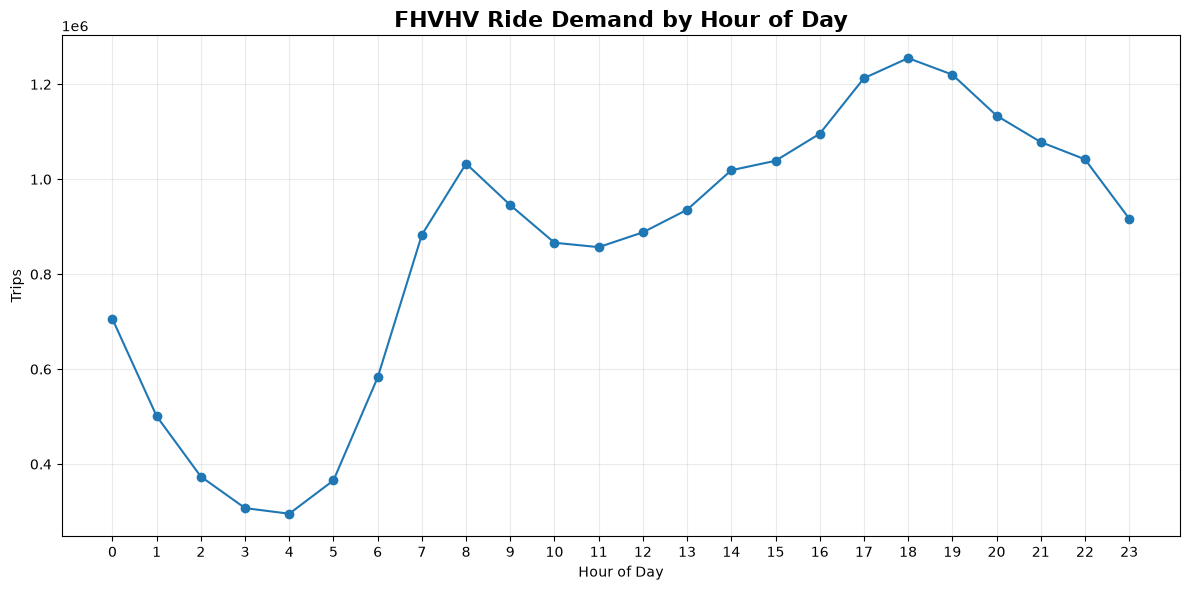

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(
    hourly_demand["request_hour"],
    hourly_demand["trips"],
    marker="o"
)
plt.title("FHVHV Ride Demand by Hour of Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Trips")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 9.2 Day × hour demand heatmap

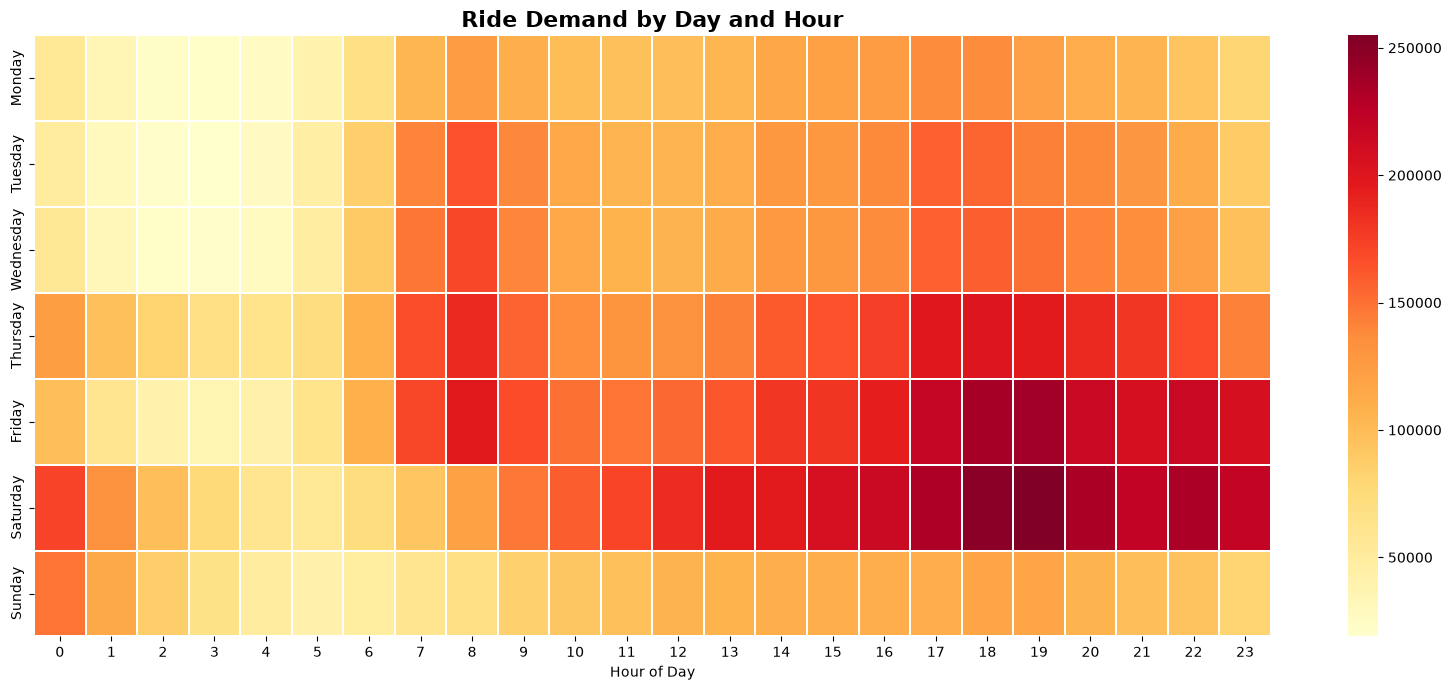

In [30]:
heatmap_data = (
    day_hour_demand
    .pivot(index="day_name", columns="request_hour", values="trips")
    .reindex(day_order)
)

plt.figure(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3
)
plt.title("Ride Demand by Day and Hour", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 9.3 Peak vs non-peak aggregate speed

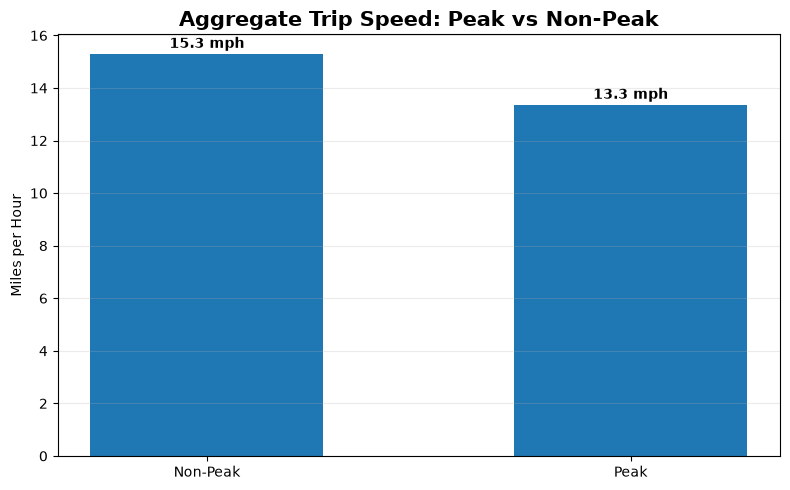

In [31]:
plot_peak = peak_performance.set_index("period").loc[
    ["Non-Peak", "Peak"]
].reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    plot_peak["period"],
    plot_peak["aggregate_speed_mph"],
    width=0.55
)

for bar, value in zip(bars, plot_peak["aggregate_speed_mph"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.25,
        f"{value:.1f} mph",
        ha="center",
        fontweight="bold"
    )

plt.title("Aggregate Trip Speed: Peak vs Non-Peak", fontsize=15, fontweight="bold")
plt.ylabel("Miles per Hour")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.4 Top pickup zones

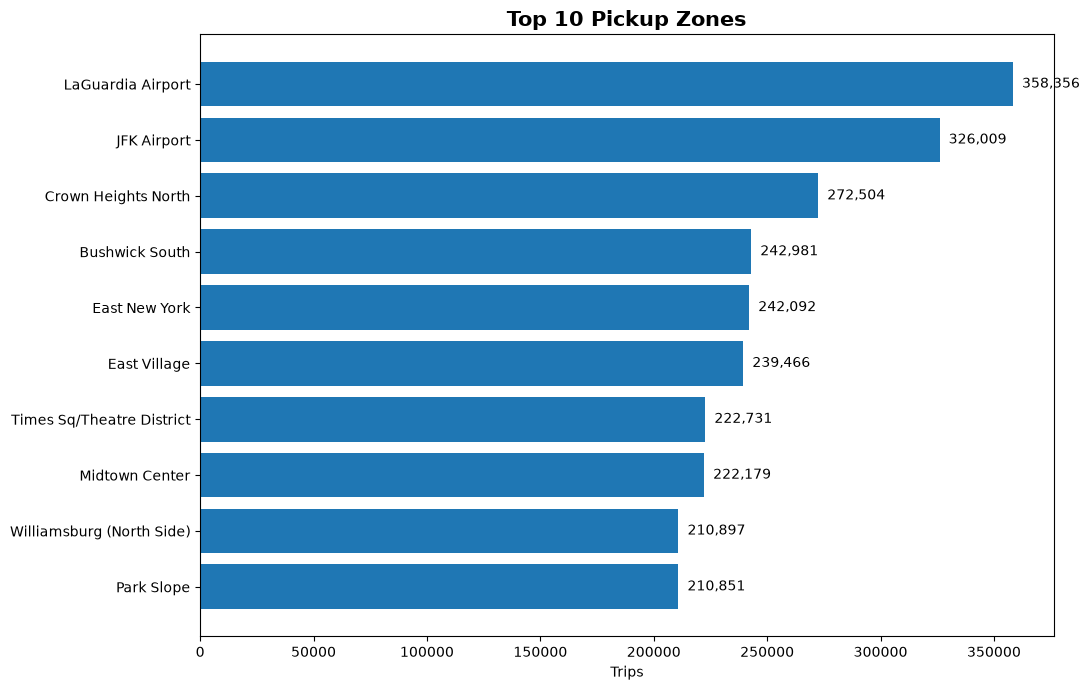

In [32]:
top_pickups = (
    pickup_named
    .sort_values("trips", ascending=False)
    .head(10)
    .sort_values("trips")
)

plt.figure(figsize=(11, 7))
bars = plt.barh(top_pickups["Zone"], top_pickups["trips"])

for bar in bars:
    value = int(bar.get_width())
    plt.text(
        value + 4_000,
        bar.get_y() + bar.get_height()/2,
        f"{value:,}",
        va="center"
    )

plt.title("Top 10 Pickup Zones", fontsize=15, fontweight="bold")
plt.xlabel("Trips")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 9.5 NYC borough pickup vs drop-off activity

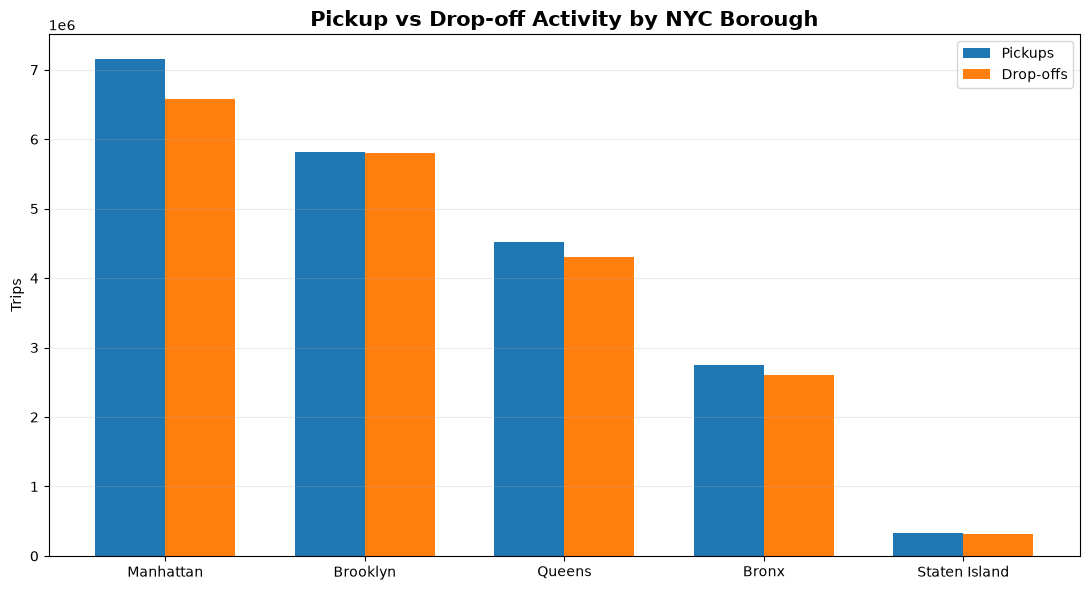

In [33]:
nyc_boroughs = [
    "Manhattan", "Brooklyn", "Queens",
    "Bronx", "Staten Island"
]

bf = (
    borough_flow[
        borough_flow["Borough"].isin(nyc_boroughs)
    ]
    .set_index("Borough")
    .loc[nyc_boroughs]
    .reset_index()
)

x = np.arange(len(bf))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, bf["pickups"], width, label="Pickups")
plt.bar(x + width/2, bf["dropoffs"], width, label="Drop-offs")

plt.xticks(x, bf["Borough"])
plt.title("Pickup vs Drop-off Activity by NYC Borough", fontsize=15, fontweight="bold")
plt.ylabel("Trips")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.6 Mobility structure

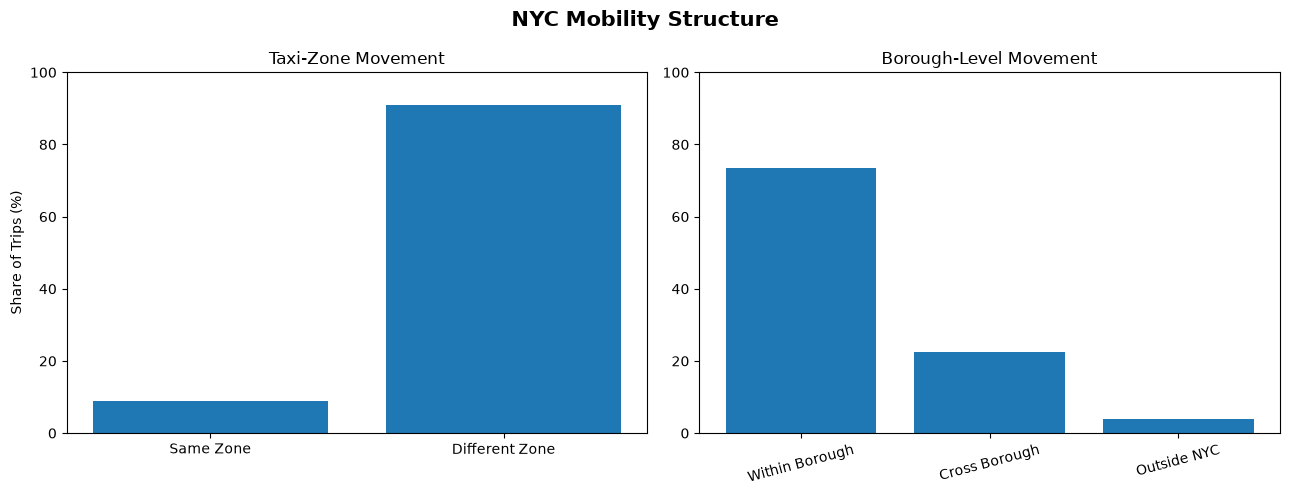

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

zm = zone_movement.sort_values("percentage")
axes[0].bar(zm["zone_movement"], zm["percentage"])
axes[0].set_title("Taxi-Zone Movement")
axes[0].set_ylabel("Share of Trips (%)")
axes[0].set_ylim(0, 100)

bm_order = ["Within Borough", "Cross Borough", "Outside NYC"]
bm = (
    borough_movement.set_index("borough_movement")
    .loc[bm_order]
    .reset_index()
)
axes[1].bar(bm["borough_movement"], bm["percentage"])
axes[1].set_title("Borough-Level Movement")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("NYC Mobility Structure", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.7 Distance distribution

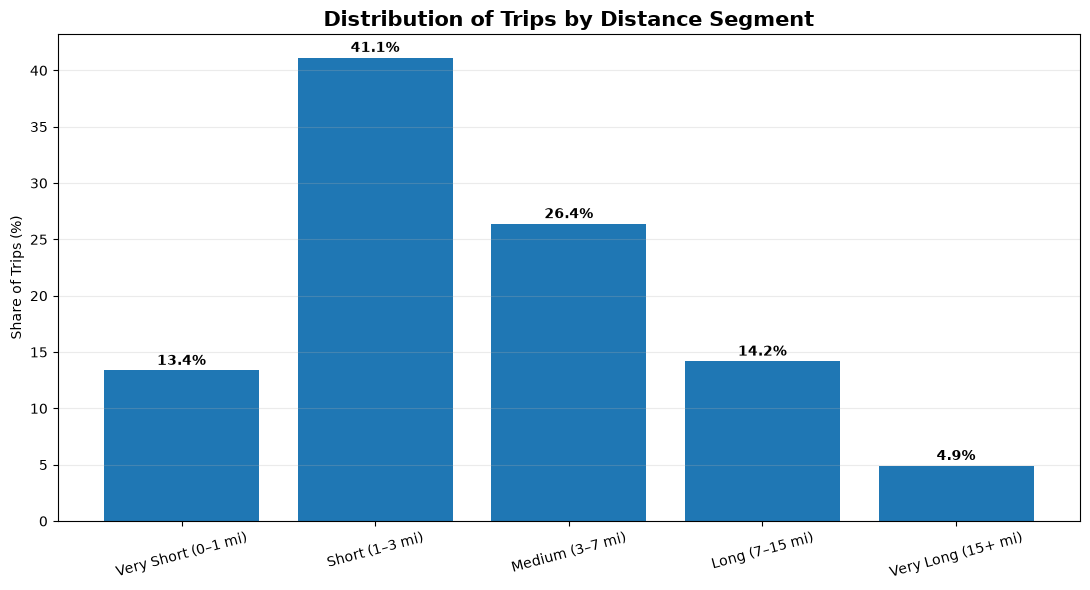

In [35]:
plt.figure(figsize=(11, 6))
bars = plt.bar(
    distance_summary["distance_segment"].astype(str),
    distance_summary["percentage"]
)

for bar, value in zip(bars, distance_summary["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Distribution of Trips by Distance Segment", fontsize=15, fontweight="bold")
plt.ylabel("Share of Trips (%)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.8 Distance segment economics

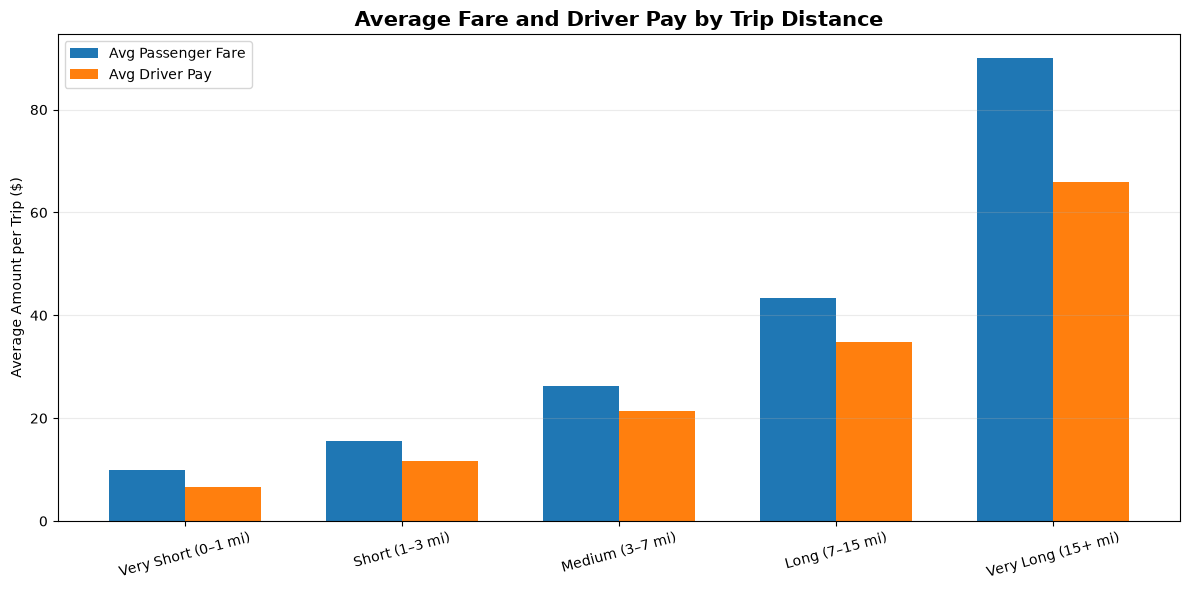

In [36]:
x = np.arange(len(segment_economics))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(
    x - width/2,
    segment_economics["avg_fare"],
    width,
    label="Avg Passenger Fare"
)
plt.bar(
    x + width/2,
    segment_economics["avg_driver_pay"],
    width,
    label="Avg Driver Pay"
)

plt.xticks(
    x,
    segment_economics["distance_segment"].astype(str),
    rotation=15
)
plt.title("Average Fare and Driver Pay by Trip Distance", fontsize=15, fontweight="bold")
plt.ylabel("Average Amount per Trip ($)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.9 Duration distribution

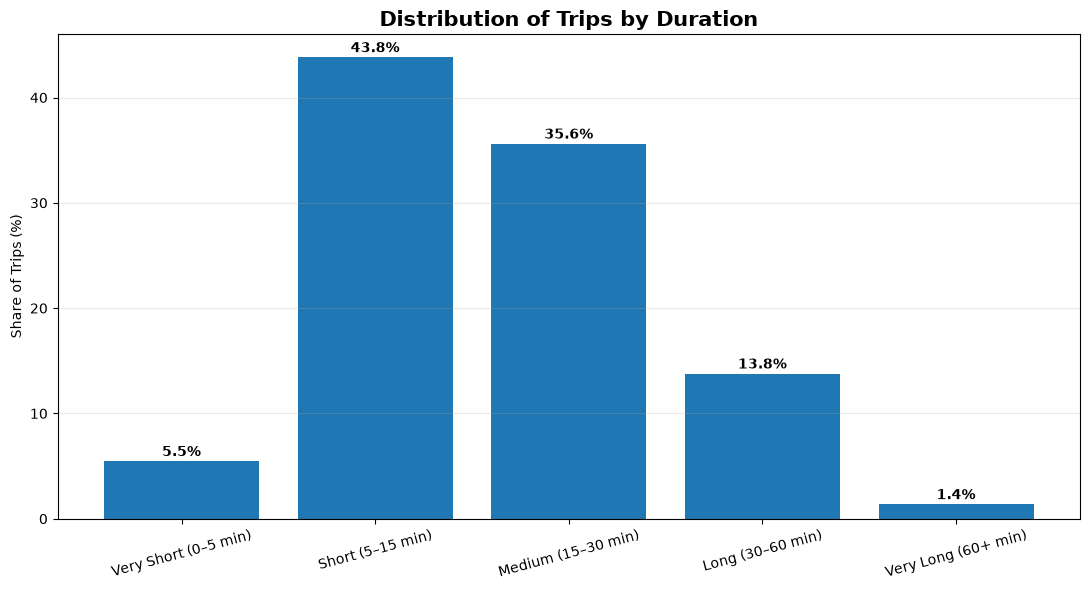

In [37]:
plt.figure(figsize=(11, 6))
bars = plt.bar(
    duration_summary["duration_segment"].astype(str),
    duration_summary["percentage"]
)

for bar, value in zip(bars, duration_summary["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Distribution of Trips by Duration", fontsize=15, fontweight="bold")
plt.ylabel("Share of Trips (%)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 9.10 Airport intelligence — LaGuardia vs JFK

In [38]:
airport_zones = zone_economics[
    zone_economics["Zone"].isin(["LaGuardia Airport", "JFK Airport"])
].copy()

airport_zones = airport_zones.merge(
    pickup_named[["PULocationID", "trips"]].rename(
        columns={"trips": "pickup_trips"}
    ),
    on="PULocationID",
    how="left"
)

airport_zones[
    [
        "Zone", "pickup_trips",
        "avg_fare", "avg_driver_pay",
        "driver_pay_per_trip_hour"
    ]
]

,Zone,pickup_trips,avg_fare,avg_driver_pay,driver_pay_per_trip_hour
0,JFK Airport,326009,76.0142,55.4041,77.8942
1,LaGuardia Airport,358356,55.5430,39.8861,75.0982


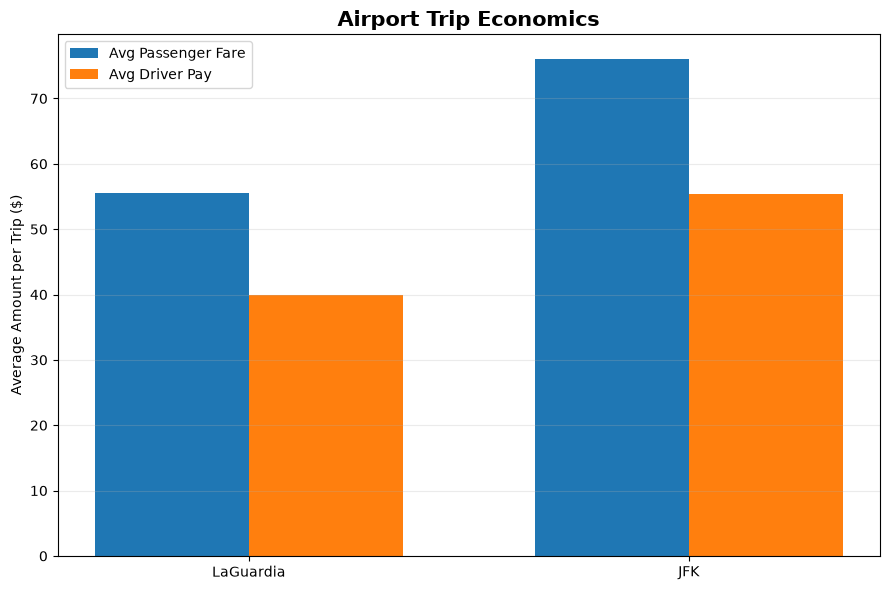

In [39]:
airport_plot = (
    airport_zones
    .set_index("Zone")
    .loc[["LaGuardia Airport", "JFK Airport"]]
    .reset_index()
)

x = np.arange(len(airport_plot))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(
    x - width/2,
    airport_plot["avg_fare"],
    width,
    label="Avg Passenger Fare"
)
plt.bar(
    x + width/2,
    airport_plot["avg_driver_pay"],
    width,
    label="Avg Driver Pay"
)

plt.xticks(x, ["LaGuardia", "JFK"])
plt.title("Airport Trip Economics", fontsize=15, fontweight="bold")
plt.ylabel("Average Amount per Trip ($)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Key Findings & Business Implications

1. **Demand is highly time-dependent.** The system peaks around 18:00, with Friday and Saturday evenings forming the strongest recurring demand periods.

2. **Peak demand comes with weaker mobility performance.** Trips in the 16:00–20:00 window are shorter on average but take slightly longer and move at lower aggregate speed.

3. **High demand does not automatically mean the highest passenger-trip-time driver pay.** Overnight hours show higher trip-time pay, while 20:00–22:00 offers a stronger balance between demand and trip-time pay.

4. **Demand is geographically dispersed.** LaGuardia and JFK are the top two individual pickup zones, but together account for only about 3.33% of total trips.

5. **Most trips cross neighborhood boundaries but remain locally concentrated at borough level.** About 91% cross a taxi-zone boundary, yet approximately 73.5% stay within the same borough.

6. **Manhattan is the largest pickup market and shows a meaningful directional imbalance.** Brooklyn is comparatively balanced between pickups and drop-offs.

7. **The marketplace is dominated by short-to-medium urban travel.** Roughly 54.5% of valid trips are three miles or less, 80.9% are seven miles or less, and about 79.4% last between 5 and 30 minutes.

8. **Trip economics change with distance.** Longer trips generate much higher fare per trip, but fare per mile declines as distance increases.

9. **Airport markets have distinct profiles.** LaGuardia has more pickup volume, while JFK-origin trips are substantially longer and higher-value on average.

10. **Core economic and mobility measures are strongly related.** Fare and driver pay show the strongest Pearson correlation, while distance is also strongly associated with fare and driver pay.

### Analytical caution
The project is observational. Findings describe associations in the January 2026 FHVHV data and should not be interpreted as causal effects without additional analysis.

Power BI export folder

In [84]:
from pathlib import Path

POWERBI_DIR = Path("powerbi_data")
POWERBI_DIR.mkdir(exist_ok=True)

print(POWERBI_DIR.resolve())

C:\Users\Hp\Desktop\Project 1\powerbi_data


Export the main KPI table

In [85]:
kpi_summary = pd.DataFrame({
    "Total Trips": [
        parquet_file.metadata.num_rows
    ],

    "Valid Trips": [
        int(overall_performance["valid_trips"])
    ],

    "Avg Distance Miles": [
        overall_performance["avg_distance_miles"]
    ],

    "Avg Duration Minutes": [
        overall_performance["avg_duration_minutes"]
    ],

    "Aggregate Speed MPH": [
        overall_performance["aggregate_speed_mph"]
    ]
})

kpi_summary

,Total Trips,Valid Trips,Avg Distance Miles,Avg Duration Minutes,Aggregate Speed MPH
0,20553794,20551246,4.5435,18.5390,14.7048


In [86]:
kpi_summary.to_csv(
    POWERBI_DIR / "KPI_Summary.csv",
    index=False
)

Add economics to the KPI table


In [87]:
economic_totals = {
    "trips": 0,
    "fare": 0,
    "driver_pay": 0
}

for i in range(parquet_file.num_row_groups):

    chunk = parquet_file.read_row_group(
        i,
        columns=[
            "base_passenger_fare",
            "driver_pay"
        ]
    ).to_pandas()

    economic_totals["trips"] += len(chunk)

    economic_totals["fare"] += (
        chunk["base_passenger_fare"].sum()
    )

    economic_totals["driver_pay"] += (
        chunk["driver_pay"].sum()
    )

In [88]:
avg_fare = (
    economic_totals["fare"]
    / economic_totals["trips"]
)

avg_driver_pay = (
    economic_totals["driver_pay"]
    / economic_totals["trips"]
)

print("Average Fare:", avg_fare)
print("Average Driver Pay:", avg_driver_pay)

Average Fare: 25.26118454091736
Average Driver Pay: 19.51733309091256


In [89]:
kpi_summary["Avg Fare"] = avg_fare

kpi_summary["Avg Driver Pay"] = avg_driver_pay

In [90]:
kpi_summary.to_csv(
    POWERBI_DIR / "KPI_Summary.csv",
    index=False
)

kpi_summary

,Total Trips,Valid Trips,Avg Distance Miles,Avg Duration Minutes,Aggregate Speed MPH,Avg Fare,Avg Driver Pay
0,20553794,20551246,4.5435,18.5390,14.7048,25.2612,19.5173


Export Hourly Demand

In [91]:
hourly_bi = hourly_demand.rename(columns={
    "request_hour": "Hour",
    "trips": "Total Trips"
})

hourly_bi

,Hour,Total Trips
0,0,705622
1,1,500905
2,2,373712
3,3,307305
4,4,295487
5,5,365692
6,6,582569
7,7,883056
8,8,1032912
9,9,945513


In [92]:
hourly_bi.to_csv(
    POWERBI_DIR / "Hourly_Demand.csv",
    index=False
)

In [93]:
daily_bi = daily_demand.copy()

daily_bi = daily_bi.rename(columns={
    "day_name": "Day",
    "trips": "Total Trips"
})

In [94]:
day_number = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7
}

daily_bi["Day Number"] = (
    daily_bi["Day"]
    .astype(str)
    .map(day_number)
)

daily_bi

,Day,Total Trips,Day Number
1,Monday,2154655,1
5,Tuesday,2481188,2
6,Wednesday,2550387,3
4,Thursday,3442752,4
0,Friday,3693173,5
2,Saturday,4001878,6
3,Sunday,2229761,7


In [95]:
daily_bi.to_csv(
    POWERBI_DIR / "Daily_Demand.csv",
    index=False
)

Export Day × Hour Demand

In [96]:
day_hour_bi = day_hour_demand.copy()

day_hour_bi = day_hour_bi.rename(columns={
    "day_name": "Day",
    "request_hour": "Hour",
    "trips": "Total Trips"
})

day_hour_bi["Day Number"] = (
    day_hour_bi["Day"]
    .map(day_number)
)

day_hour_bi.head()

,Day,Hour,Total Trips,Day Number
0,Friday,0,98195,5
1,Friday,1,60240,5
2,Friday,2,40902,5
3,Friday,3,36199,5
4,Friday,4,42847,5


In [97]:
day_hour_bi.to_csv(
    POWERBI_DIR / "Day_Hour_Demand.csv",
    index=False
)

Export Zone Demand

In [98]:
pickup_bi = pickup_named[
    ["PULocationID", "Borough", "Zone", "trips"]
].copy()

pickup_bi = pickup_bi.rename(columns={
    "PULocationID": "Location ID",
    "trips": "Pickup Trips"
})

pickup_bi.head()

,Location ID,Borough,Zone,Pickup Trips
0,1,EWR,Newark Airport,1
1,2,Queens,Jamaica Bay,29
2,3,Bronx,Allerton/Pelham Gardens,50073
3,4,Manhattan,Alphabet City,54345
4,5,Staten Island,Arden Heights,6066


In [99]:
pickup_bi.to_csv(
    POWERBI_DIR / "Pickup_Zone_Demand.csv",
    index=False
)

In [100]:
dropoff_bi = dropoff_named[
    ["DOLocationID", "Borough", "Zone", "trips"]
].copy()

dropoff_bi = dropoff_bi.rename(columns={
    "DOLocationID": "Location ID",
    "trips": "Dropoff Trips"
})

dropoff_bi.to_csv(
    POWERBI_DIR / "Dropoff_Zone_Demand.csv",
    index=False
)

In [101]:
nyc_boroughs = [
    "Manhattan",
    "Brooklyn",
    "Queens",
    "Bronx",
    "Staten Island"
]

borough_bi = borough_flow[
    borough_flow["Borough"].isin(nyc_boroughs)
].copy()

borough_bi

,Borough,pickups,dropoffs,net_flow
0,Bronx,"2,743,399.0000",2604138,"-139,261.0000"
1,Brooklyn,"5,814,405.0000",5807829,"-6,576.0000"
3,Manhattan,"7,152,427.0000",6584106,"-568,321.0000"
4,Queens,"4,513,490.0000",4308968,"-204,522.0000"
5,Staten Island,"329,075.0000",320500,"-8,575.0000"


In [102]:
borough_bi = borough_bi.rename(columns={
    "pickups": "Pickup Trips",
    "dropoffs": "Dropoff Trips",
    "net_flow": "Net Flow"
})

In [103]:
borough_bi["Net Flow %"] = (
    borough_bi["Net Flow"]
    / borough_bi["Pickup Trips"]
    * 100
)

In [104]:
borough_bi.to_csv(
    POWERBI_DIR / "Borough_Flow.csv",
    index=False
)

Mobility Structure

In [105]:
zone_movement_bi = zone_movement.rename(columns={
    "zone_movement": "Movement Type",
    "trips": "Total Trips",
    "percentage": "Percentage"
})

zone_movement_bi["Level"] = "Taxi Zone"

In [106]:
borough_movement_bi = borough_movement.rename(columns={
    "borough_movement": "Movement Type",
    "trips": "Total Trips",
    "percentage": "Percentage"
})

borough_movement_bi["Level"] = "Borough"

In [107]:
mobility_structure_bi = pd.concat(
    [
        zone_movement_bi,
        borough_movement_bi
    ],
    ignore_index=True
)

mobility_structure_bi

,Movement Type,Total Trips,Percentage,Level
0,Different Zone,18706682,91.0133,Taxi Zone
1,Same Zone,1847112,8.9867,Taxi Zone
2,Cross Borough,4623223,22.4933,Borough
3,Outside NYC,819240,3.9858,Borough
4,Within Borough,15111331,73.5209,Borough


In [108]:
mobility_structure_bi.to_csv(
    POWERBI_DIR / "Mobility_Structure.csv",
    index=False
)

Airport Intelligence

In [109]:
airport_bi = zone_performance[
    zone_performance["Zone"].isin([
        "LaGuardia Airport",
        "JFK Airport"
    ])
][[
    "PULocationID",
    "Zone",
    "trips",
    "avg_distance",
    "avg_duration_min"
]].copy()

In [110]:
airport_bi = airport_bi.rename(columns={
    "Zone": "Airport",
    "trips": "Pickup Trips",
    "avg_distance": "Avg Distance",
    "avg_duration_min": "Avg Duration"
})

In [111]:
airport_economics = zone_economics[
    zone_economics["Zone"].isin([
        "LaGuardia Airport",
        "JFK Airport"
    ])
][[
    "PULocationID",
    "avg_fare",
    "avg_driver_pay",
    "driver_pay_per_trip_hour"
]].copy()

In [112]:
airport_bi = airport_bi.merge(
    airport_economics,
    on="PULocationID",
    how="left",
    validate="one_to_one"
)

In [113]:
airport_bi = airport_bi.rename(columns={
    "avg_fare": "Avg Fare",
    "avg_driver_pay": "Avg Driver Pay",
    "driver_pay_per_trip_hour": "Driver Pay per Trip Hour"
})

airport_bi

,PULocationID,Airport,Pickup Trips,Avg Distance,Avg Duration,Avg Fare,Avg Driver Pay,Driver Pay per Trip Hour
0,132,JFK Airport,325958,17.7404,42.6765,76.0142,55.4041,77.8942
1,138,LaGuardia Airport,358352,11.2297,31.8671,55.5430,39.8861,75.0982


In [114]:
airport_bi.to_csv(
    POWERBI_DIR / "Airport_Analysis.csv",
    index=False
)

Peak performance

In [115]:
peak_performance_bi = peak_performance.rename(columns={
    "period": "Period",
    "trips": "Trips",
    "avg_distance": "Avg Distance",
    "avg_duration_min": "Avg Duration",
    "aggregate_speed_mph": "Aggregate Speed"
})

peak_performance_bi.to_csv(
    POWERBI_DIR / "Peak_Performance.csv",
    index=False
)

peak_performance_bi

,Period,Trips,miles,seconds,Avg Distance,Avg Duration,Aggregate Speed
0,Non-Peak,14633399,"68,324,420.0900",16099991643,4.6691,18.3370,15.2775
1,Peak,5917847,"25,050,669.9130",6759982135,4.2331,19.0384,13.3406


peak_economics

In [116]:
peak_economics_bi = peak_economics.rename(columns={
    "period": "Period",
    "trips": "Trips",
    "total_miles": "Total Miles",
    "total_fare": "Total Fare",
    "total_driver_pay": "Total Driver Pay",
    "total_tips": "Total Tips",
    "avg_fare": "Avg Fare",
    "avg_driver_pay": "Avg Driver Pay",
    "avg_tip": "Avg Tip",
    "fare_per_mile": "Fare per Mile",
    "driver_pay_per_mile": "Driver Pay per Mile"
})

peak_economics_bi.to_csv(
    POWERBI_DIR / "Peak_Economics.csv",
    index=False
)

peak_economics_bi

,Period,Trips,Total Miles,Total Fare,Total Driver Pay,Total Tips,Avg Fare,Avg Driver Pay,Avg Tip,Fare per Mile,Driver Pay per Mile
0,Non-Peak,14633399,"68,324,420.0900","371,546,647.9300","286,732,911.0100","16,336,232.3400",25.3903,19.5944,1.1164,5.4380,4.1966
1,Peak,5917847,"25,050,669.9130","147,629,785.8500","114,395,812.6700","6,839,622.5000",24.9465,19.3306,1.1558,5.8932,4.5666


distance_segments

In [117]:
distance_segments_bi = segment_economics.rename(columns={
    "distance_segment": "Distance Segment",
    "trips": "Trips",
    "avg_distance": "Avg Distance",
    "avg_duration_min": "Avg Duration",
    "avg_fare": "Avg Fare",
    "avg_driver_pay": "Avg Driver Pay",
    "fare_per_mile": "Fare per Mile",
    "driver_pay_per_trip_hour": "Driver Pay per Trip Hour"
})

In [118]:
distance_share = distance_summary.rename(columns={
    "distance_segment": "Distance Segment",
    "percentage": "Trip Share %"
})[
    ["Distance Segment", "Trip Share %"]
]

In [119]:
distance_segments_bi = distance_segments_bi.merge(
    distance_share,
    on="Distance Segment",
    how="left",
    validate="one_to_one"
)

In [120]:
distance_order = {
    "Very Short (0–1 mi)": 1,
    "Short (1–3 mi)": 2,
    "Medium (3–7 mi)": 3,
    "Long (7–15 mi)": 4,
    "Very Long (15+ mi)": 5
}

distance_segments_bi["Sort Order"] = (
    distance_segments_bi["Distance Segment"]
    .astype(str)
    .map(distance_order)
)

In [121]:
distance_segments_bi.to_csv(
    POWERBI_DIR / "Distance_Segments.csv",
    index=False
)

distance_segments_bi

,Distance Segment,Trips,total_miles,total_seconds,total_fare,total_driver_pay,Avg Distance,Avg Duration,Avg Fare,Avg Driver Pay,Fare per Mile,Driver Pay per Trip Hour,Trip Share %,Sort Order
0,Very Short (0–1 mi),2746495,"2,023,508.7020",1038085650,"27,100,804.5100","18,052,194.0500",0.7368,6.2995,9.8674,6.5728,13.3930,62.6036,13.3641,1
1,Short (1–3 mi),8455598,"15,517,550.5540",6317091695,"132,111,228.5600","98,786,421.9100",1.8352,12.4515,15.6241,11.6830,8.5137,56.2967,41.1440,2
2,Medium (3–7 mi),5423012,"24,921,266.8370",7084417250,"142,248,402.0800","115,889,517.7600",4.5955,21.7727,26.2305,21.3700,5.7079,58.8901,26.3878,3
3,Long (7–15 mi),2915037,"28,925,790.4310",5480859816,"126,584,811.4900","101,767,713.3400",9.9230,31.3367,43.4248,34.9113,4.3762,66.8442,14.1843,4
4,Very Long (15+ mi),1011064,"21,986,639.9090",2939404817,"91,131,168.5000","66,633,268.5800",21.7460,48.4540,90.1339,65.9041,4.1448,81.6083,4.9197,5


duration_segments

In [123]:
duration_segments_bi = duration_summary.rename(columns={
    "duration_segment": "Duration Segment",
    "trips": "Trips",
    "percentage": "Trip Share %"
})

In [124]:
duration_order = {
    "Very Short (0–5 min)": 1,
    "Short (5–15 min)": 2,
    "Medium (15–30 min)": 3,
    "Long (30–60 min)": 4,
    "Very Long (60+ min)": 5
}

duration_segments_bi["Sort Order"] = (
    duration_segments_bi["Duration Segment"]
    .astype(str)
    .map(duration_order)
)

In [125]:
duration_segments_bi.to_csv(
    POWERBI_DIR / "Duration_Segments.csv",
    index=False
)

duration_segments_bi

,Duration Segment,Trips,Trip Share %,Sort Order
0,Very Short (0–5 min),1121109,5.4547,1
1,Short (5–15 min),9004770,43.8122,2
2,Medium (15–30 min),7317241,35.6017,3
3,Long (30–60 min),2829918,13.7688,4
4,Very Long (60+ min),280051,1.3626,5


Service summary

In [126]:
service_bi = service_summary.reset_index()

In [127]:
service_bi = service_bi.rename(columns={
    "index": "Service Metric",
    "Y": "Yes Trips",
    "N": "No Trips",
    "total": "Total Trips",
    "yes_rate_pct": "Yes Rate %"
})

In [128]:

service_names = {
    "shared_request_flag": "Shared Ride Requested",
    "shared_match_flag": "Shared Ride Matched",
    "access_a_ride_flag": "Access-A-Ride",
    "wav_request_flag": "WAV Requested",
    "wav_match_flag": "WAV Matched"
}

service_bi["Service Metric"] = (
    service_bi["Service Metric"]
    .map(service_names)
)

In [129]:
service_bi.to_csv(
    POWERBI_DIR / "Service_Summary.csv",
    index=False
)

service_bi

,Service Metric,Yes Trips,No Trips,Total Trips,Yes Rate %
0,Shared Ride Requested,388092,20165702,20553794,1.8882
1,Shared Ride Matched,227658,20326136,20553794,1.1076
2,Access-A-Ride,18516,20535278,20553794,0.0901
3,WAV Requested,38223,20515571,20553794,0.1860
4,WAV Matched,1873392,18680402,20553794,9.1146


In [130]:
sorted([
    file.name
    for file in POWERBI_DIR.iterdir()
])

['Airport_Analysis.csv',
 'Borough_Flow.csv',
 'Daily_Demand.csv',
 'Day_Hour_Demand.csv',
 'Distance_Segments.csv',
 'Dropoff_Zone_Demand.csv',
 'Duration_Segments.csv',
 'Hourly_Demand.csv',
 'KPI_Summary.csv',
 'Mobility_Structure.csv',
 'Peak_Economics.csv',
 'Peak_Performance.csv',
 'Pickup_Zone_Demand.csv',
 'Service_Summary.csv']